### **Setup & Load Data**

#### Imports


In [3]:
import sys; sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from collections import Counter
from src.utils.config import FEATURES_CSV_PATH, CLASSES_CSV_PATH, EDGELIST_CSV_PATH

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

#### Load 3 CSV files

In [4]:
all_cols = ['txId', 'time_step'] + [f'local_{i}' for i in range(93)] + [f'agg_{i}' for i in range(72)]
df_feat = pd.read_csv(FEATURES_CSV_PATH, header=None, names=all_cols)
df_feat['txId'] = df_feat['txId'].astype('int64')

df_cls = pd.read_csv(CLASSES_CSV_PATH)
df_cls['txId'] = df_cls['txId'].astype('int64')
df_cls['class'] = df_cls['class'].astype(str)

df_edges = pd.read_csv(EDGELIST_CSV_PATH)
df_edges.columns = ['txId1', 'txId2']

print(f"Nodes (transactions):  {len(df_feat):,}")
print(f"Edges (fund flows):    {len(df_edges):,}")
print(f"Edge / Node ratio:     {len(df_edges)/len(df_feat):.3f}")
print(f"\nClass distribution:\n{df_cls['class'].value_counts()}")
print(f"\nFeatures shape: {df_feat.shape}")
print(f"Time steps: {df_feat['time_step'].nunique()} (range {df_feat['time_step'].min()}–{df_feat['time_step'].max()})")

Nodes (transactions):  203,769
Edges (fund flows):    234,355
Edge / Node ratio:     1.150

Class distribution:
class
unknown    157205
2           42019
1            4545
Name: count, dtype: int64

Features shape: (203769, 167)
Time steps: 49 (range 1–49)


### **Class Imbalance & Temporal Distribution**

#### Class pie chart + bar per time step

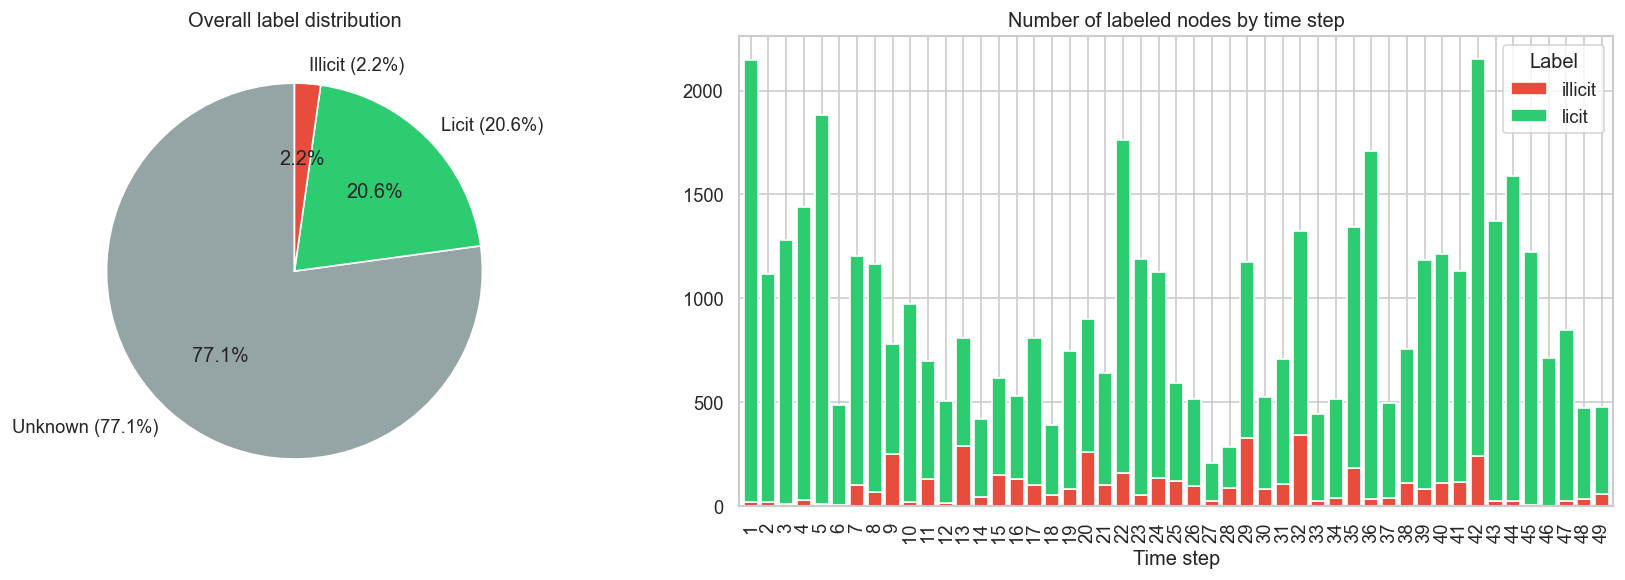

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

counts = df_cls['class'].value_counts()
labels = ['Unknown (77.1%)', 'Licit (20.6%)', 'Illicit (2.2%)']
colors = ['#95a5a6', '#2ecc71', '#e74c3c']
axes[0].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Overall label distribution')

# Bar: labeled nodes per time step
df_merged = df_feat[['txId','time_step']].merge(df_cls, on='txId')
df_labeled = df_merged[df_merged['class'] != 'unknown']
df_labeled['label'] = df_labeled['class'].map({'1':'illicit','2':'licit'})
ct = df_labeled.groupby(['time_step','label']).size().unstack(fill_value=0)
ct.plot(kind='bar', stacked=True, ax=axes[1], color=['#e74c3c','#2ecc71'], width=0.8)
axes[1].set_title('Number of labeled nodes by time step')
axes[1].set_xlabel('Time step')
axes[1].legend(title='Label')
plt.tight_layout(); plt.show()

#### Nodes per time step (all vs labeled)

In [6]:
nodes_per_ts = df_feat.groupby('time_step').size().rename('total_nodes')
print("Nodes per time step:")
print(f"  Mean:   {nodes_per_ts.mean():.0f}")
print(f"  Median: {nodes_per_ts.median():.0f}")
print(f"  Min:    {nodes_per_ts.min()} (ts={nodes_per_ts.idxmin()})")
print(f"  Max:    {nodes_per_ts.max()} (ts={nodes_per_ts.idxmax()})")

Nodes per time step:
  Mean:   4159
  Median: 4291
  Min:    1089 (ts=27)
  Max:    7880 (ts=1)


### **Degree Analysis**

#### Compute degree, degree statistics + histogram

=== Degree Statistics ===

in_degree:
  mean=1.15, median=1, max=284
  % nodes with in_degree=0: 27.1%
  % nodes with in_degree=1: 63.2%
  % nodes with in_degree>1: 9.6%

out_degree:
  mean=1.15, median=1, max=472
  % nodes with out_degree=0: 18.4%
  % nodes with out_degree=1: 60.4%
  % nodes with out_degree>1: 21.2%

total_degree:
  mean=2.30, median=2, max=473
  % nodes with total_degree=0: 0.0%
  % nodes with total_degree=1: 34.5%
  % nodes with total_degree>1: 65.5%


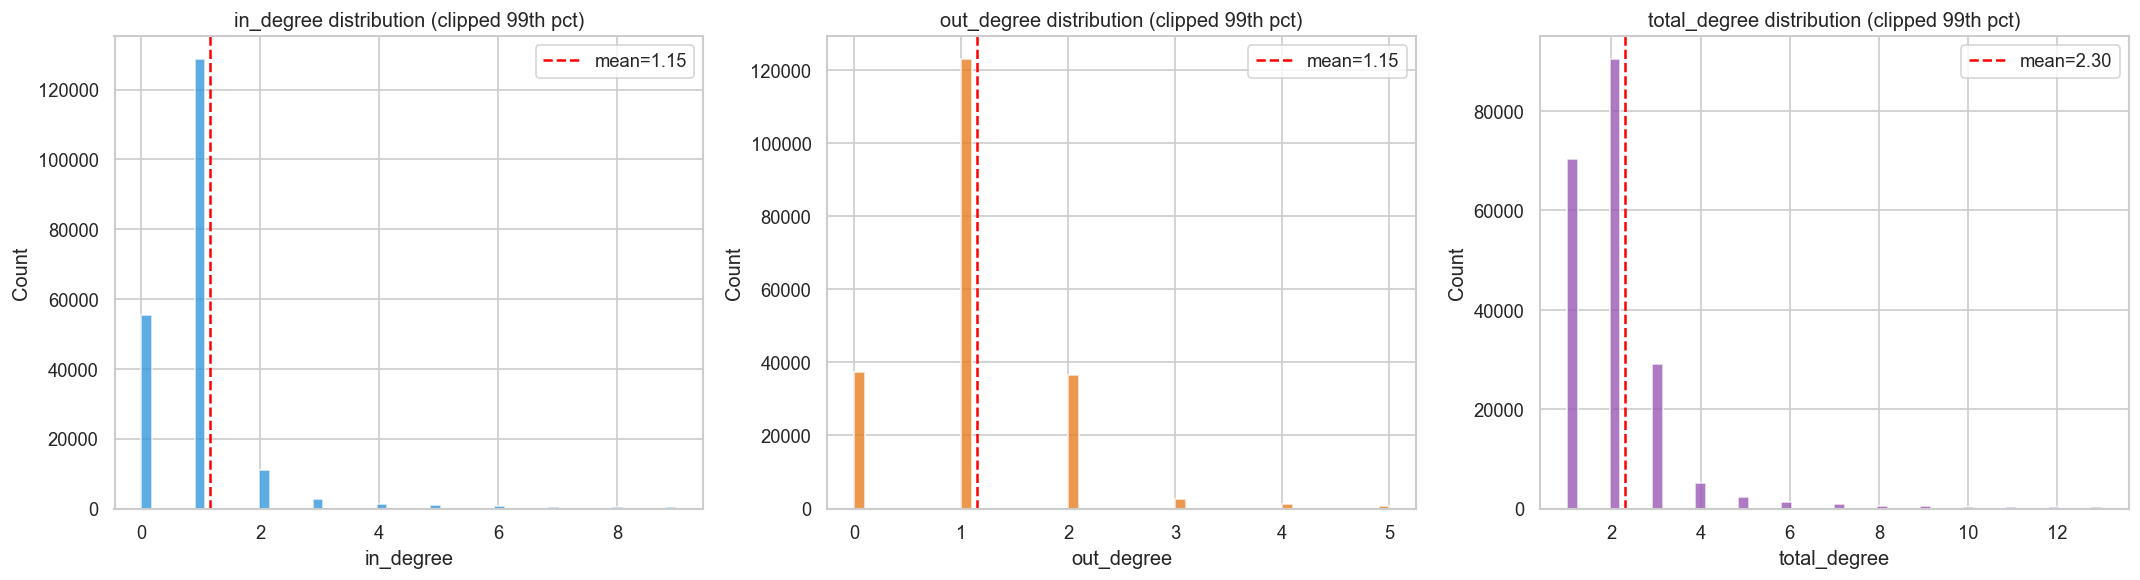

In [7]:
in_deg  = df_edges.groupby('txId2').size().rename('in_degree')
out_deg = df_edges.groupby('txId1').size().rename('out_degree')

df_deg = df_feat[['txId']].copy()
df_deg = df_deg.merge(in_deg, left_on='txId', right_index=True, how='left')
df_deg = df_deg.merge(out_deg, left_on='txId', right_index=True, how='left')
df_deg[['in_degree','out_degree']] = df_deg[['in_degree','out_degree']].fillna(0).astype(int)
df_deg['total_degree'] = df_deg['in_degree'] + df_deg['out_degree']

print("=== Degree Statistics ===")
for col in ['in_degree', 'out_degree', 'total_degree']:
    s = df_deg[col]
    print(f"\n{col}:")
    print(f"  mean={s.mean():.2f}, median={s.median():.0f}, max={s.max()}")
    print(f"  % nodes with {col}=0: {(s==0).mean()*100:.1f}%")
    print(f"  % nodes with {col}=1: {(s==1).mean()*100:.1f}%")
    print(f"  % nodes with {col}>1: {(s>1).mean()*100:.1f}%")

# Histograms
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col, color in zip(axes, ['in_degree','out_degree','total_degree'], ['#3498db','#e67e22','#9b59b6']):
    data = df_deg[col]
    data_clipped = data[data <= data.quantile(0.99)]  # clip outliers for viz
    ax.hist(data_clipped, bins=50, color=color, edgecolor='white', alpha=0.8)
    ax.set_title(f'{col} distribution (clipped 99th pct)')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.axvline(data.mean(), color='red', linestyle='--', label=f'mean={data.mean():.2f}')
    ax.legend()
plt.tight_layout(); plt.show()


#### Degree breakdown table

In [8]:
rows = []
for col in ['in_degree', 'out_degree']:
    s = df_deg[col]
    rows.append({
        'metric': col,
        'nodes_deg_0': f"{(s==0).sum():,} ({(s==0).mean()*100:.1f}%)",
        'nodes_deg_1': f"{(s==1).sum():,} ({(s==1).mean()*100:.1f}%)",
        'nodes_deg_2+': f"{(s>=2).sum():,} ({(s>=2).mean()*100:.1f}%)",
        'max': s.max(),
    })
print(pd.DataFrame(rows).to_string(index=False))

print(f"\nNodes with in_degree > 1 (multiple funding sources): {(df_deg['in_degree']>1).sum():,}")
print(f"Nodes with out_degree > 1 (money is divided among many): {(df_deg['out_degree']>1).sum():,}")

    metric    nodes_deg_0     nodes_deg_1   nodes_deg_2+  max
 in_degree 55,322 (27.1%) 128,859 (63.2%)  19,588 (9.6%)  284
out_degree 37,424 (18.4%) 123,175 (60.4%) 43,170 (21.2%)  472

Nodes with in_degree > 1 (multiple funding sources): 19,588
Nodes with out_degree > 1 (money is divided among many): 43,170


### **Graph Topology**

#### Build graph & check DAG, components

In [9]:
G = nx.from_pandas_edgelist(df_edges, 'txId1', 'txId2', create_using=nx.DiGraph())

nodes_in_graph = set(G.nodes())
all_nodes = set(df_feat['txId'])
isolated_nodes = all_nodes - nodes_in_graph

print(f"Nodes in edgelist:   {len(nodes_in_graph):,}")
print(f"Isolated nodes:      {len(isolated_nodes):,} ({len(isolated_nodes)/len(all_nodes)*100:.1f}%)")
print(f"Total nodes:         {len(all_nodes):,}")
print(f"\nIs DAG (no cycles):  {nx.is_directed_acyclic_graph(G)}")

wccs = list(nx.weakly_connected_components(G))
wcc_sizes = sorted([len(c) for c in wccs], reverse=True)
print(f"\nWeakly Connected Components: {len(wccs):,}")
print(f"Largest WCC: {wcc_sizes[0]:,} nodes ({wcc_sizes[0]/len(nodes_in_graph)*100:.1f}%)")
print(f"Top 10 WCC sizes: {wcc_sizes[:10]}")
print(f"Components with 1 node (pairs only): {sum(1 for s in wcc_sizes if s <= 2):,}")

Nodes in edgelist:   203,769
Isolated nodes:      0 (0.0%)
Total nodes:         203,769

Is DAG (no cycles):  True

Weakly Connected Components: 49
Largest WCC: 7,880 nodes (3.9%)
Top 10 WCC sizes: [7880, 7140, 6803, 6727, 6621, 6393, 6048, 5894, 5693, 5598]
Components with 1 node (pairs only): 0


#### Component size distribution

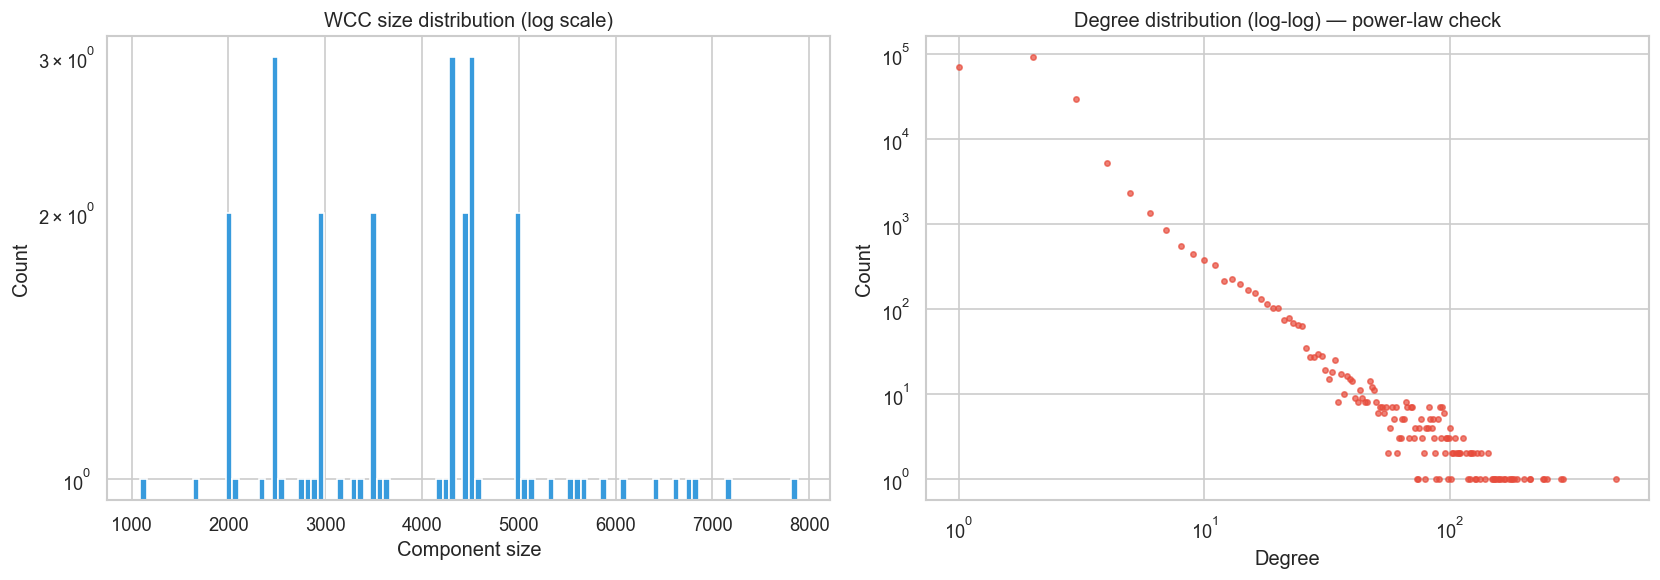

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# WCC size distribution (log scale)
axes[0].hist(wcc_sizes, bins=100, color="#389bdd", edgecolor='white')
axes[0].set_yscale('log')
axes[0].set_title('WCC size distribution (log scale)')
axes[0].set_xlabel('Component size')
axes[0].set_ylabel('Count')

# Degree distribution (log-log)
degree_seq = sorted([d for _, d in G.degree()], reverse=True)
deg_count = Counter(degree_seq)
degs, counts = zip(*sorted(deg_count.items()))
axes[1].scatter(degs, counts, s=10, alpha=0.7, color='#e74c3c')
axes[1].set_xscale('log'); axes[1].set_yscale('log')
axes[1].set_title('Degree distribution (log-log) — power-law check')
axes[1].set_xlabel('Degree'); axes[1].set_ylabel('Count')
plt.tight_layout(); plt.show()

### **Temporal Edge Analysis**

#### Cross-time edge analysis

In [11]:
tx_time = df_feat.set_index('txId')['time_step']
df_e = df_edges.copy()
df_e['src_ts'] = df_e['txId1'].map(tx_time)
df_e['dst_ts'] = df_e['txId2'].map(tx_time)
df_e['time_diff'] = df_e['dst_ts'] - df_e['src_ts']

same = (df_e['time_diff'] == 0).sum()
forward = (df_e['time_diff'] > 0).sum()
backward = (df_e['time_diff'] < 0).sum()

print(f"Same time step:     {same:,} ({same/len(df_e)*100:.1f}%)")
print(f"Forward (src→dst):  {forward:,} ({forward/len(df_e)*100:.1f}%)")
print(f"Backward (dst→src): {backward:,} ({backward/len(df_e)*100:.1f}%)")
print(f"\nTime diff distribution:")
print(df_e['time_diff'].describe())

Same time step:     234,355 (100.0%)
Forward (src→dst):  0 (0.0%)
Backward (dst→src): 0 (0.0%)

Time diff distribution:
count    234355.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: time_diff, dtype: float64


#### Heatmap time_diff + edges per time step

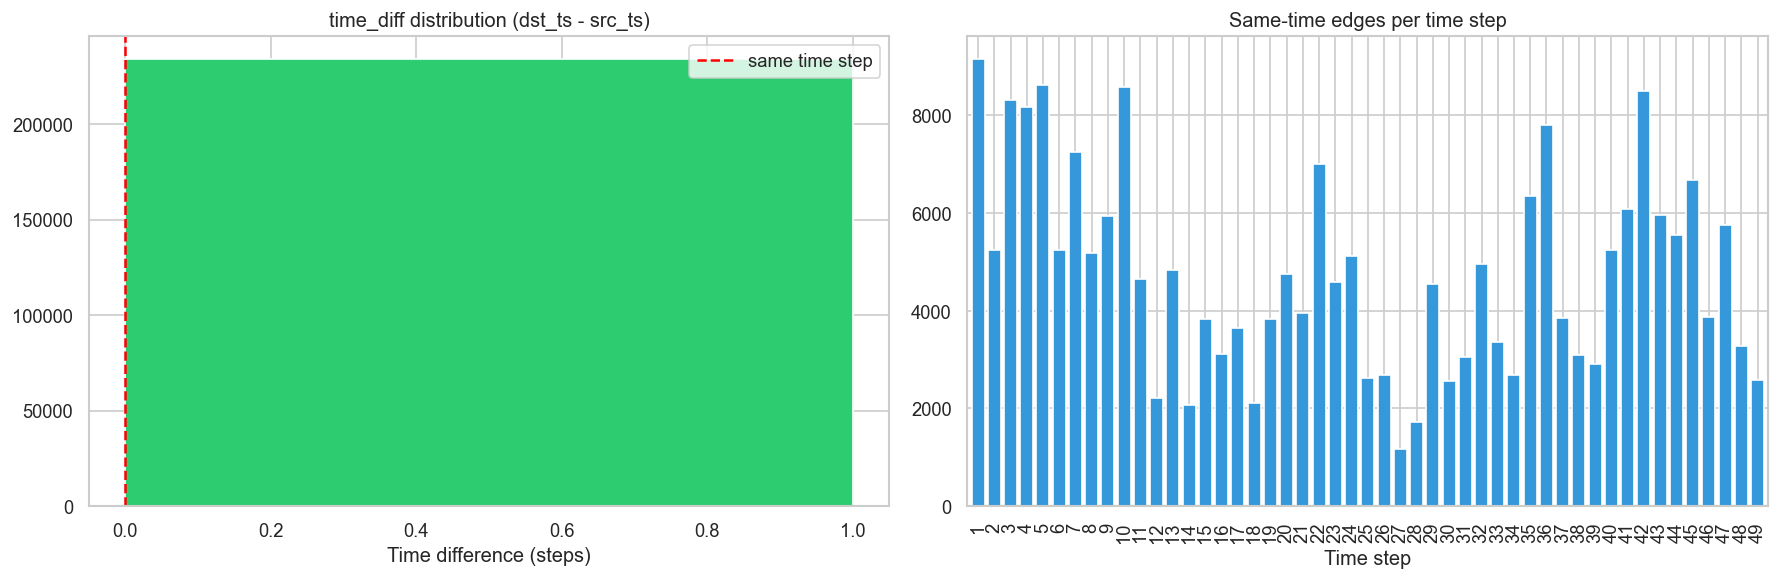

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Time diff histogram
df_e['time_diff'].hist(bins=range(df_e['time_diff'].min(), df_e['time_diff'].max()+2),
                        ax=axes[0], color='#2ecc71', edgecolor='white')
axes[0].set_title('time_diff distribution (dst_ts - src_ts)')
axes[0].set_xlabel('Time difference (steps)')
axes[0].axvline(0, color='red', linestyle='--', label='same time step')
axes[0].legend()

# Edges per time step (same-time only)
same_edges_per_ts = df_e[df_e['time_diff']==0].groupby('src_ts').size()
same_edges_per_ts.plot(kind='bar', ax=axes[1], color='#3498db', width=0.8)
axes[1].set_title('Same-time edges per time step')
axes[1].set_xlabel('Time step')
plt.tight_layout(); plt.show()


### **Class vs Degree Pattern**

#### Degree comparison by class

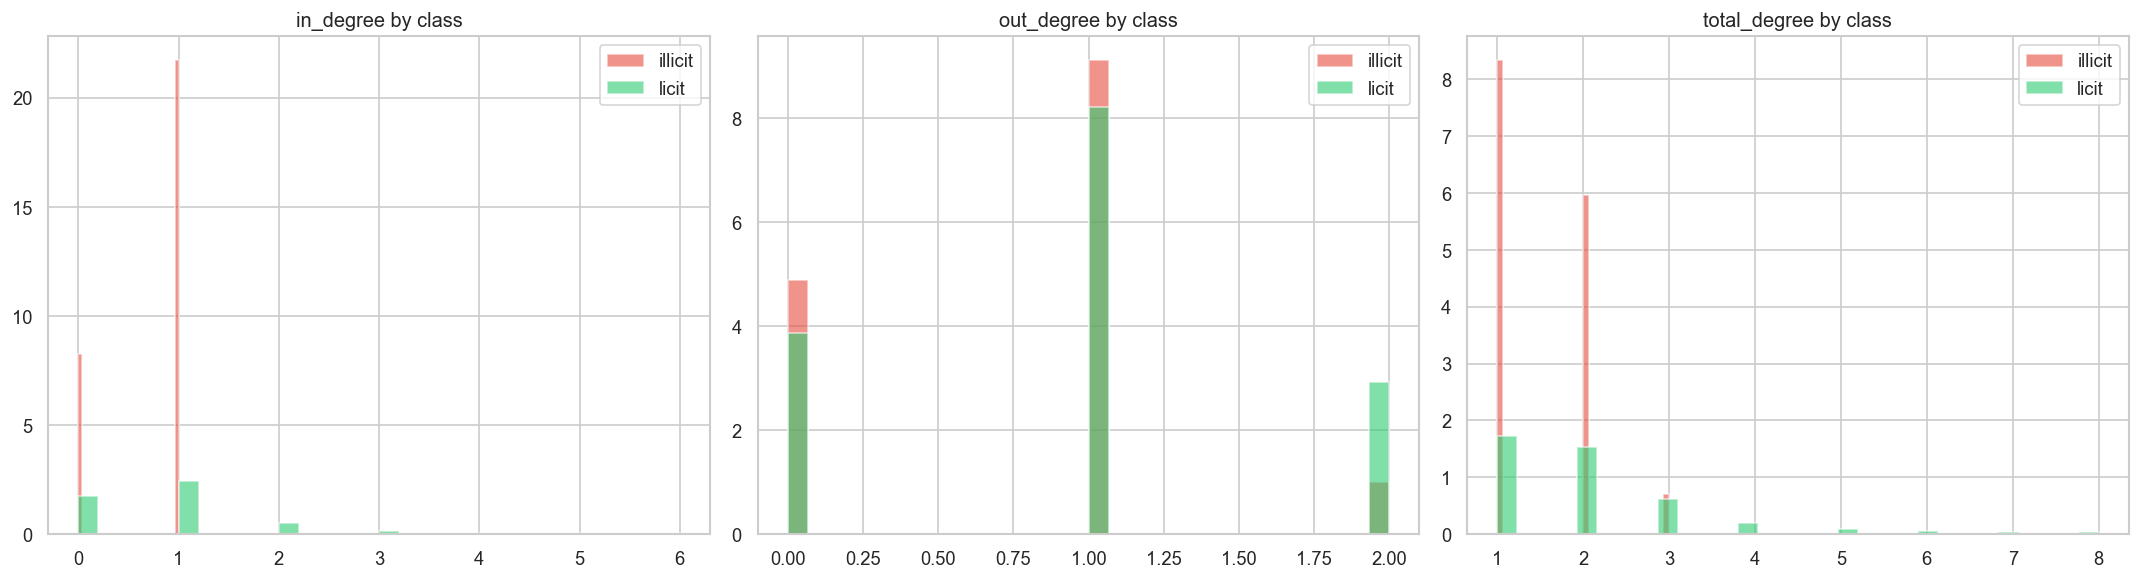

label                   illicit         licit
in_degree    count  4545.000000  42019.000000
             mean      1.269967      1.909398
             std       7.215218      7.122538
             min       0.000000      0.000000
             25%       0.000000      0.000000
             50%       1.000000      1.000000
             75%       1.000000      1.000000
             max     177.000000    284.000000
out_degree   count  4545.000000  42019.000000
             mean      0.741694      1.185821
             std       0.571620      3.246769
             min       0.000000      0.000000
             25%       0.000000      1.000000
             50%       1.000000      1.000000
             75%       1.000000      1.000000
             max       3.000000    472.000000
total_degree count  4545.000000  42019.000000
             mean      2.011661      3.095219
             std       7.177521      7.782942
             min       1.000000      1.000000
             25%       1.000000   

In [13]:
df_analysis = df_deg.merge(df_cls, on='txId')
df_analysis = df_analysis[df_analysis['class'] != 'unknown']
df_analysis['label'] = df_analysis['class'].map({'1': 'illicit', '2': 'licit'})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ['in_degree', 'out_degree', 'total_degree']):
    for label, color in [('illicit', '#e74c3c'), ('licit', '#2ecc71')]:
        data = df_analysis[df_analysis['label']==label][col]
        data_clip = data[data <= data.quantile(0.95)]
        ax.hist(data_clip, bins=30, alpha=0.6, color=color, label=label, density=True)
    ax.set_title(f'{col} by class')
    ax.legend()
plt.tight_layout(); plt.show()

# Stats table
print(df_analysis.groupby('label')[['in_degree','out_degree','total_degree']].describe().T)

### **Subgraph Visualization**

#### Visualize 1 time step subgraph

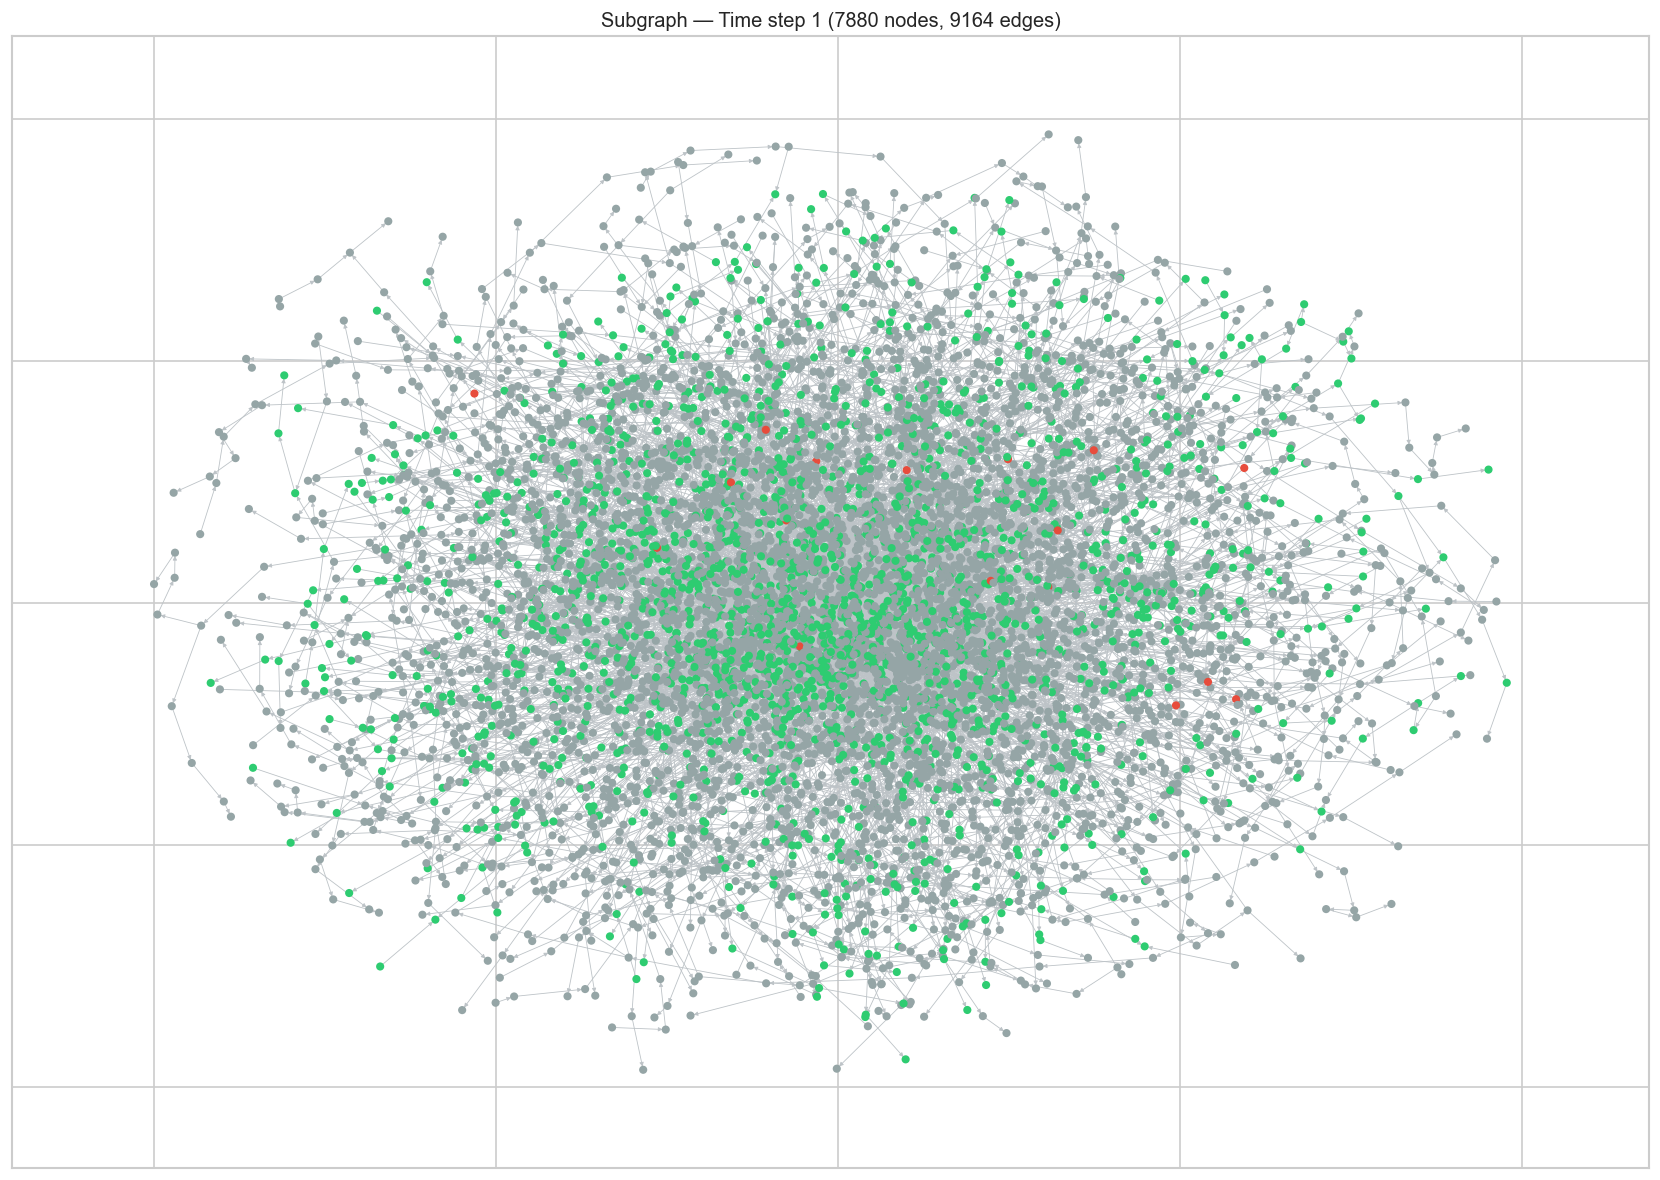

In [14]:
target_ts = 1
ts_nodes = set(df_feat[df_feat['time_step']==target_ts]['txId'])
ts_edges = df_edges[df_edges['txId1'].isin(ts_nodes) & df_edges['txId2'].isin(ts_nodes)]
G_sub = nx.from_pandas_edgelist(ts_edges, 'txId1', 'txId2', create_using=nx.DiGraph())

cls_map = dict(zip(df_cls['txId'], df_cls['class']))
colors = []
for n in G_sub.nodes():
    c = cls_map.get(n, 'unknown')
    colors.append('#e74c3c' if c=='1' else '#2ecc71' if c=='2' else '#95a5a6')

fig, ax = plt.subplots(1, 1, figsize=(14, 10))
pos = nx.spring_layout(G_sub, k=0.3, seed=42)
nx.draw_networkx(G_sub, pos, node_color=colors, node_size=15, 
                  with_labels=False, arrows=True, arrowsize=5,
                  edge_color='#bdc3c7', width=0.5, ax=ax)
ax.set_title(f'Subgraph — Time step {target_ts} ({G_sub.number_of_nodes()} nodes, {G_sub.number_of_edges()} edges)')
plt.tight_layout(); plt.show()

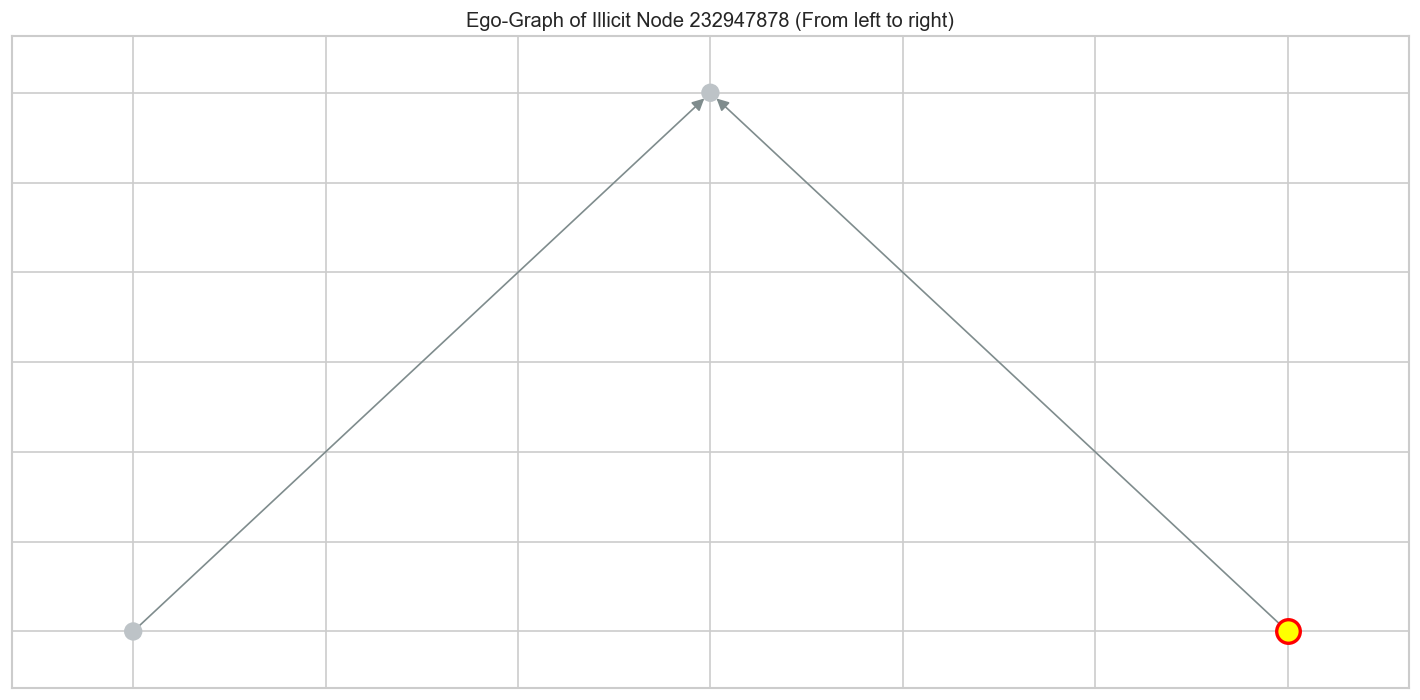

In [15]:
import networkx as nx
import matplotlib.pyplot as plt

illicit_nodes = [n for n in G_sub.nodes() if cls_map.get(n) == '1']
target_node = illicit_nodes[0] 

G_undirected = G_sub.to_undirected()
neighborhood = nx.single_source_shortest_path_length(G_undirected, target_node, cutoff=2).keys()
G_focus = G_sub.subgraph(neighborhood).copy()

for node in G_focus.nodes():
    try:
        path = nx.shortest_path_length(G_focus, source=target_node, target=node)
        G_focus.nodes[node]['layer'] = path
    except nx.NetworkXNoPath:
        try:
            path = nx.shortest_path_length(G_focus, source=node, target=target_node)
            G_focus.nodes[node]['layer'] = -path
        except nx.NetworkXNoPath:
            G_focus.nodes[node]['layer'] = 0

colors = []
for n in G_focus.nodes():
    c = cls_map.get(n, 'unknown')
    colors.append('#e74c3c' if c=='1' else '#2ecc71' if c=='2' else '#bdc3c7')

fig, ax = plt.subplots(figsize=(12, 6))
pos = nx.multipartite_layout(G_focus, subset_key="layer", align="horizontal")

nx.draw_networkx(G_focus, pos, node_color=colors, node_size=100, 
                 with_labels=False, arrows=True, arrowsize=15,
                 edge_color='#7f8c8d', width=1.0, ax=ax)

nx.draw_networkx_nodes(G_focus, pos, nodelist=[target_node], 
                       node_color='yellow', node_size=200, edgecolors='red', linewidths=2, ax=ax)

ax.set_title(f'Ego-Graph of Illicit Node {target_node} (From left to right)')
plt.tight_layout()
plt.show()

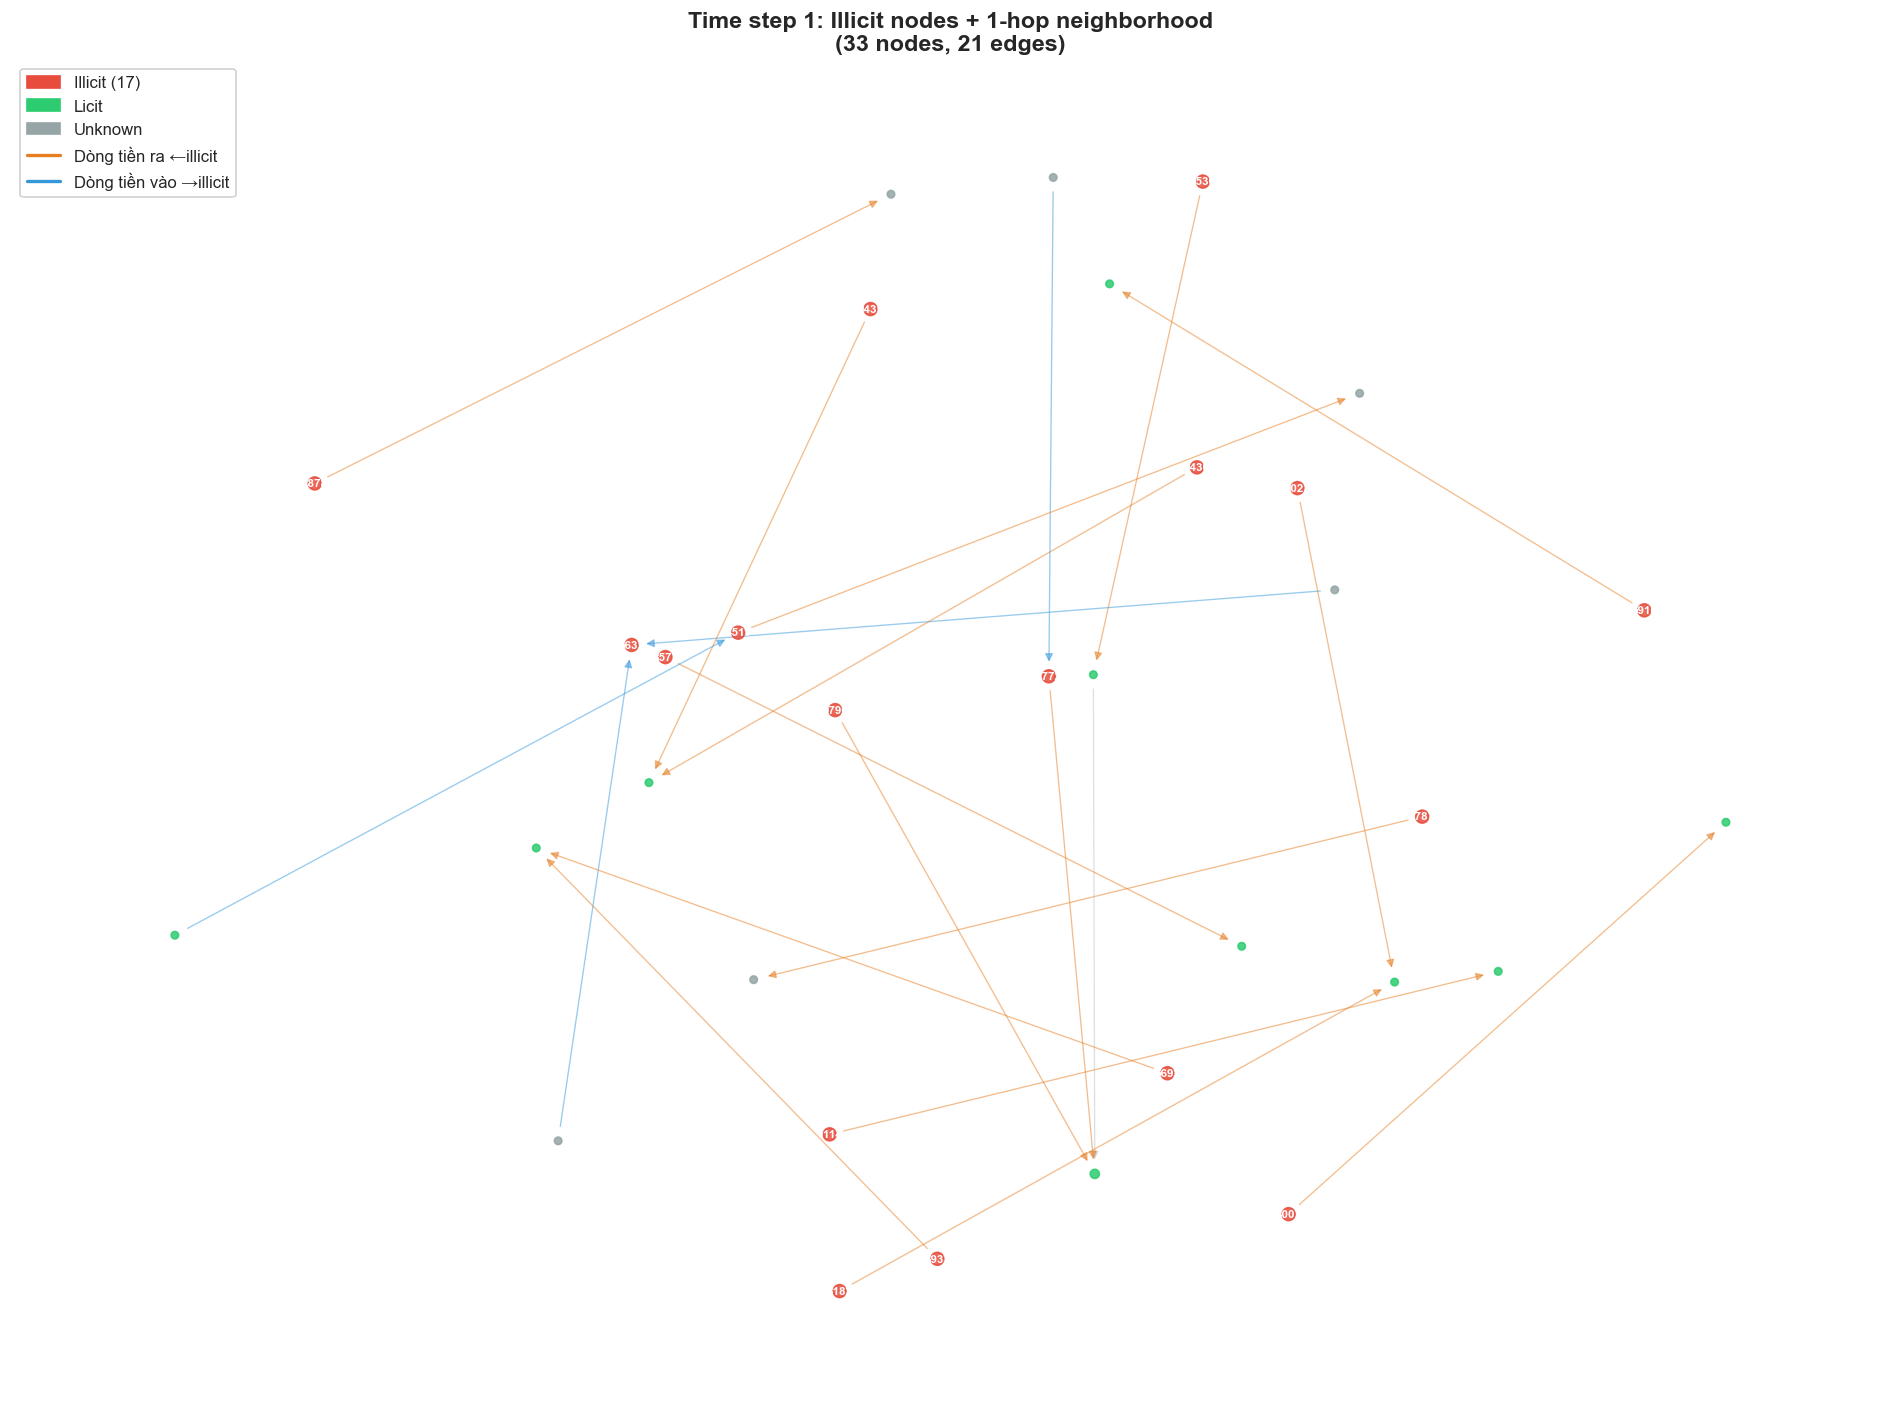

In [16]:
import matplotlib.patches as mpatches

target_ts = 1
ts_nodes = set(df_feat[df_feat['time_step']==target_ts]['txId'])
ts_edges = df_edges[df_edges['txId1'].isin(ts_nodes) & df_edges['txId2'].isin(ts_nodes)]
G_sub = nx.from_pandas_edgelist(ts_edges, 'txId1', 'txId2', create_using=nx.DiGraph())
cls_map = dict(zip(df_cls['txId'], df_cls['class']))

# ── Chỉ giữ illicit nodes + 1-hop neighbors ──────────────────────────────────
illicit_in_ts = [n for n in G_sub.nodes() if cls_map.get(n) == '1']
focus_nodes = set(illicit_in_ts)
for n in illicit_in_ts:
    focus_nodes.update(G_sub.predecessors(n))
    focus_nodes.update(G_sub.successors(n))

G_focus = G_sub.subgraph(focus_nodes).copy()

# ── Màu & kích thước ─────────────────────────────────────────────────────────
def node_style(n):
    c = cls_map.get(n, 'unknown')
    color = '#e74c3c' if c=='1' else '#2ecc71' if c=='2' else '#95a5a6'
    size  = max(60, G_focus.degree(n) * 25) if c=='1' else max(20, G_focus.degree(n) * 10)
    return color, size

colors, sizes = zip(*[node_style(n) for n in G_focus.nodes()])

# ── Edge color: cam nếu xuất phát từ illicit, xanh nếu đến illicit ───────────
edge_colors = []
for u, v in G_focus.edges():
    if cls_map.get(u) == '1':
        edge_colors.append('#e67e22')   # dòng tiền ra
    elif cls_map.get(v) == '1':
        edge_colors.append('#3498db')   # dòng tiền vào
    else:
        edge_colors.append('#bdc3c7')

fig, ax = plt.subplots(figsize=(16, 12))
pos = nx.kamada_kawai_layout(G_focus)   # tốt hơn spring_layout cho graph thưa

nx.draw_networkx_edges(G_focus, pos, edge_color=edge_colors, alpha=0.5,
                        arrows=True, arrowsize=10, width=0.8, ax=ax)
nx.draw_networkx_nodes(G_focus, pos, node_color=list(colors),
                        node_size=list(sizes), alpha=0.85, ax=ax)

# Label chỉ cho illicit nodes (4 số cuối để tránh rối)
nx.draw_networkx_labels(G_focus, pos,
    labels={n: str(n)[-4:] for n in G_focus.nodes() if cls_map.get(n)=='1'},
    font_size=7, font_color='white', font_weight='bold', ax=ax)

legend = [
    mpatches.Patch(color='#e74c3c', label=f'Illicit ({len(illicit_in_ts)})'),
    mpatches.Patch(color='#2ecc71', label='Licit'),
    mpatches.Patch(color='#95a5a6', label='Unknown'),
    plt.Line2D([0],[0], color='#e67e22', lw=2, label='Dòng tiền ra ←illicit'),
    plt.Line2D([0],[0], color='#3498db', lw=2, label='Dòng tiền vào →illicit'),
]
ax.legend(handles=legend, loc='upper left', fontsize=10, framealpha=0.9)
ax.set_title(f'Time step {target_ts}: Illicit nodes + 1-hop neighborhood\n'
             f'({G_focus.number_of_nodes()} nodes, {G_focus.number_of_edges()} edges)',
             fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout(); plt.show()

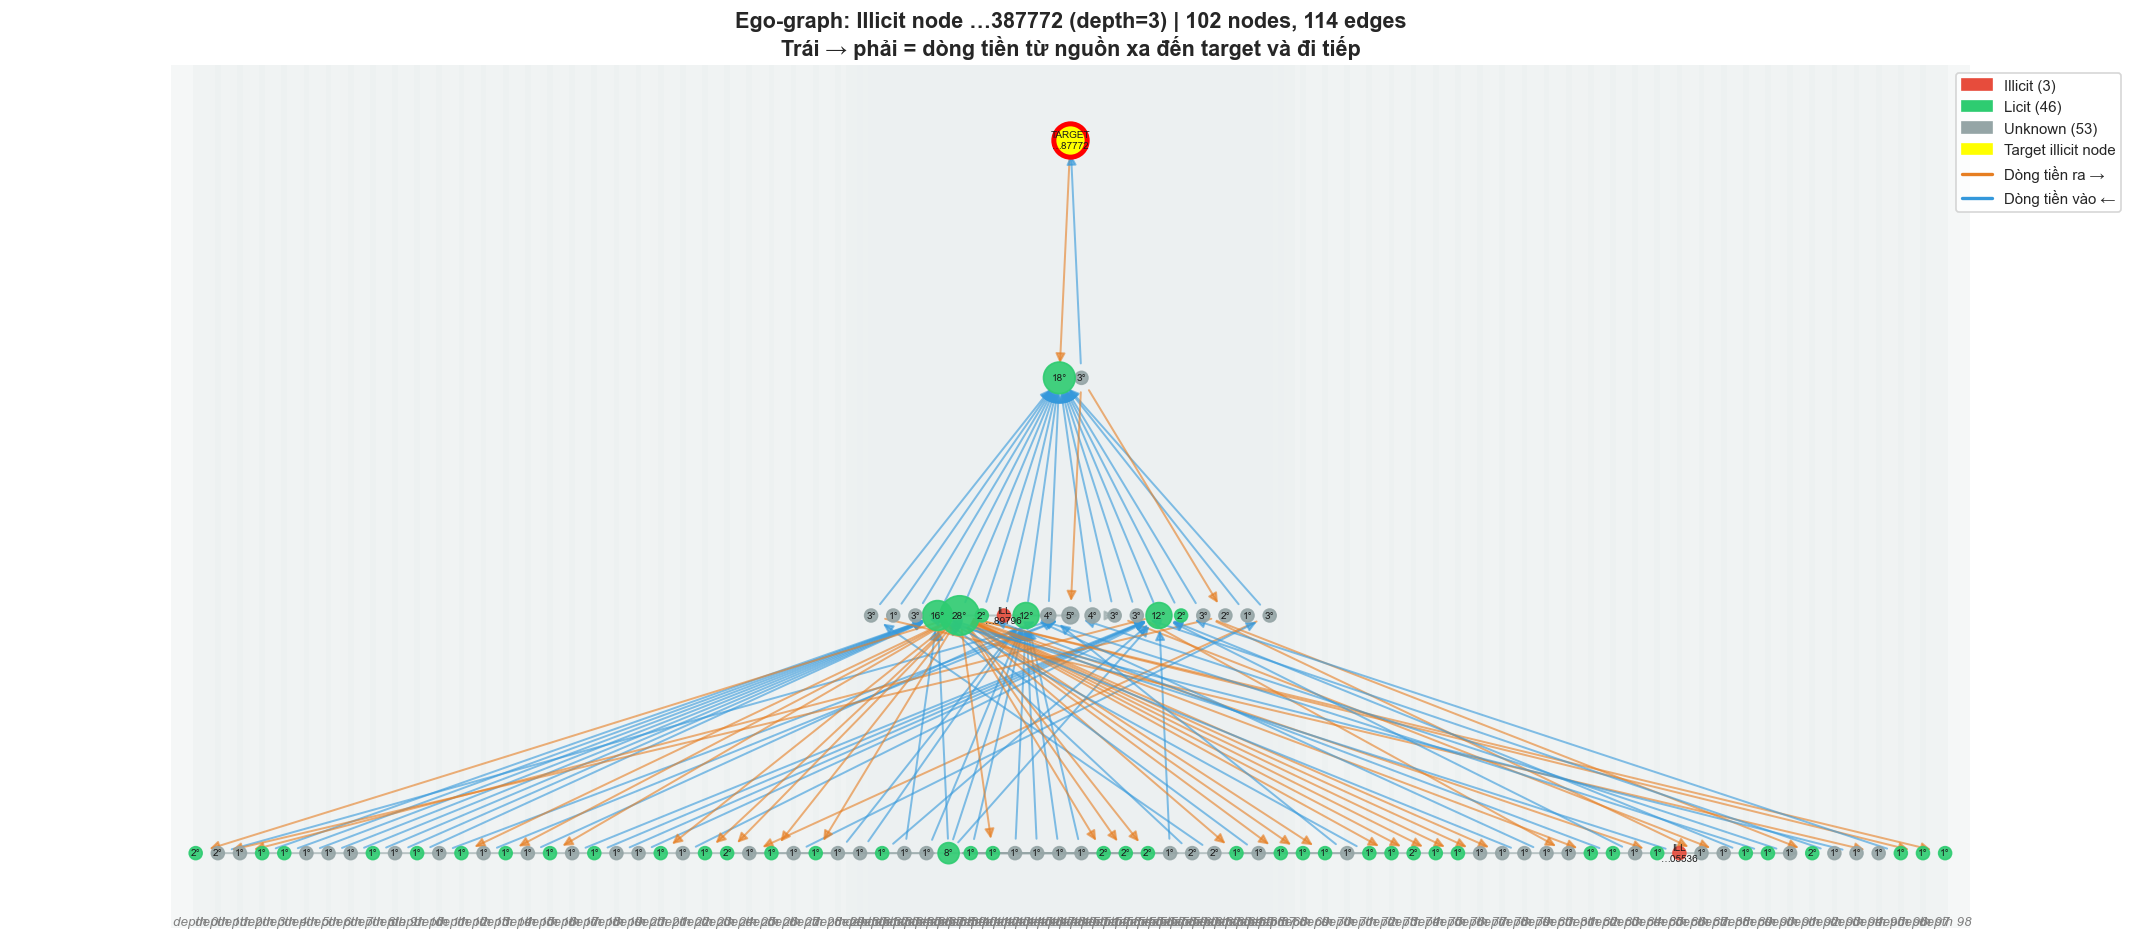

In [17]:
from collections import Counter

# ── Chọn illicit node có NHIỀU KẾT NỐI NHẤT thay vì illicit_nodes[0] ────────
illicit_in_ts = [n for n in G_sub.nodes() if cls_map.get(n) == '1']
target_node = max(illicit_in_ts, key=lambda n: G_sub.degree(n))

# ── Lấy neighborhood radius=3 ────────────────────────────────────────────────
G_und = G_sub.to_undirected()
dist_map = nx.single_source_shortest_path_length(G_und, target_node, cutoff=3)
G_ego = G_sub.subgraph(dist_map.keys()).copy()

# Gán layer = khoảng cách từ target (dùng undirected để không mất node)
nx.set_node_attributes(G_ego, dist_map, 'layer')

# ── Màu node ─────────────────────────────────────────────────────────────────
node_colors, node_sizes = [], []
for n in G_ego.nodes():
    c = cls_map.get(n, 'unknown')
    node_colors.append('#e74c3c' if c=='1' else '#2ecc71' if c=='2' else '#95a5a6')
    node_sizes.append(max(60, G_ego.degree(n) * 20))

# ── Màu edge theo chiều dòng tiền ────────────────────────────────────────────
edge_colors = []
for u, v in G_ego.edges():
    lu = dist_map.get(u, 0)
    lv = dist_map.get(v, 0)
    if lv > lu:
        edge_colors.append('#e67e22')   # dòng tiền ra (xa target)
    elif lv < lu:
        edge_colors.append('#3498db')   # dòng tiền vào (gần target)
    else:
        edge_colors.append('#95a5a6')

fig, ax = plt.subplots(figsize=(18, 8))

# multipartite_layout dọc → chuyển thành ngang (x↔y)
pos_raw = nx.multipartite_layout(G_ego, subset_key='layer', align='vertical')
pos = {n: (p[1], -p[0]) for n, p in pos_raw.items()}   # rotate 90°

nx.draw_networkx_edges(G_ego, pos, edge_color=edge_colors, alpha=0.6,
                        arrows=True, arrowsize=12, width=1.2, ax=ax)
nx.draw_networkx_nodes(G_ego, pos, node_color=node_colors,
                        node_size=node_sizes, alpha=0.9, ax=ax)

# Đánh dấu target node
nx.draw_networkx_nodes(G_ego, pos, nodelist=[target_node],
    node_color='yellow', node_size=400, edgecolors='red', linewidths=3, ax=ax)

# Label: degree cho tất cả, tên rút gọn cho illicit
labels = {n: f"{G_ego.degree(n)}°" for n in G_ego.nodes() if cls_map.get(n)!='1'}
labels.update({n: f"ILL\n…{str(n)[-5:]}" for n in G_ego.nodes() if cls_map.get(n)=='1'})
labels[target_node] = f"TARGET\n…{str(target_node)[-5:]}"
nx.draw_networkx_labels(G_ego, pos, labels=labels, font_size=6, ax=ax)

# Chú thích layer (depth)
x_vals = sorted(set(p[0] for p in pos.values()))
for depth, xv in enumerate(x_vals):
    ax.axvline(xv, color='#ecf0f1', linewidth=30, zorder=0, alpha=0.5)
    ax.text(xv, ax.get_ylim()[0] if ax.get_ylim() else -1,
            f'depth {depth}', ha='center', va='bottom',
            fontsize=8, color='gray', style='italic')

cnt = Counter([cls_map.get(n,'unknown') for n in G_ego.nodes()])
legend = [
    mpatches.Patch(color='#e74c3c', label=f"Illicit ({cnt.get('1',0)})"),
    mpatches.Patch(color='#2ecc71', label=f"Licit ({cnt.get('2',0)})"),
    mpatches.Patch(color='#95a5a6', label=f"Unknown ({cnt.get('unknown',0)})"),
    mpatches.Patch(color='yellow', label='Target illicit node'),
    plt.Line2D([0],[0], color='#e67e22', lw=2, label='Dòng tiền ra →'),
    plt.Line2D([0],[0], color='#3498db', lw=2, label='Dòng tiền vào ←'),
]
ax.legend(handles=legend, loc='upper right', fontsize=9)
ax.set_title(
    f'Ego-graph: Illicit node …{str(target_node)[-6:]} (depth=3) | '
    f'{G_ego.number_of_nodes()} nodes, {G_ego.number_of_edges()} edges\n'
    f'Trái → phải = dòng tiền từ nguồn xa đến target và đi tiếp',
    fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout(); plt.show()

C:\Users\duong\AppData\Local\Temp\ipykernel_17784\443212447.py:141: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\duong\AppData\Local\Temp\ipykernel_17784\443212447.py:141: UserWarning: Glyph 8634 (\N{ANTICLOCKWISE OPEN CIRCLE ARROW}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\duong\AppData\Local\Temp\ipykernel_17784\443212447.py:142: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.savefig('timestep1_overview.png', dpi=150, bbox_inches='tight')
C:\Users\duong\AppData\Local\Temp\ipykernel_17784\443212447.py:142: UserWarning: Glyph 8634 (\N{ANTICLOCKWISE OPEN CIRCLE ARROW}) missing from font(s) Arial.
  plt.savefig('timestep1_overview.png', dpi=150, bbox_inches='tight')
d:\Document\2025.2\IT5023E_Graduation_Research_1\transaction-network-analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8634 (\N{ANTICLOCKWISE OPEN CIRCLE ARROW}) missing from font(s) A

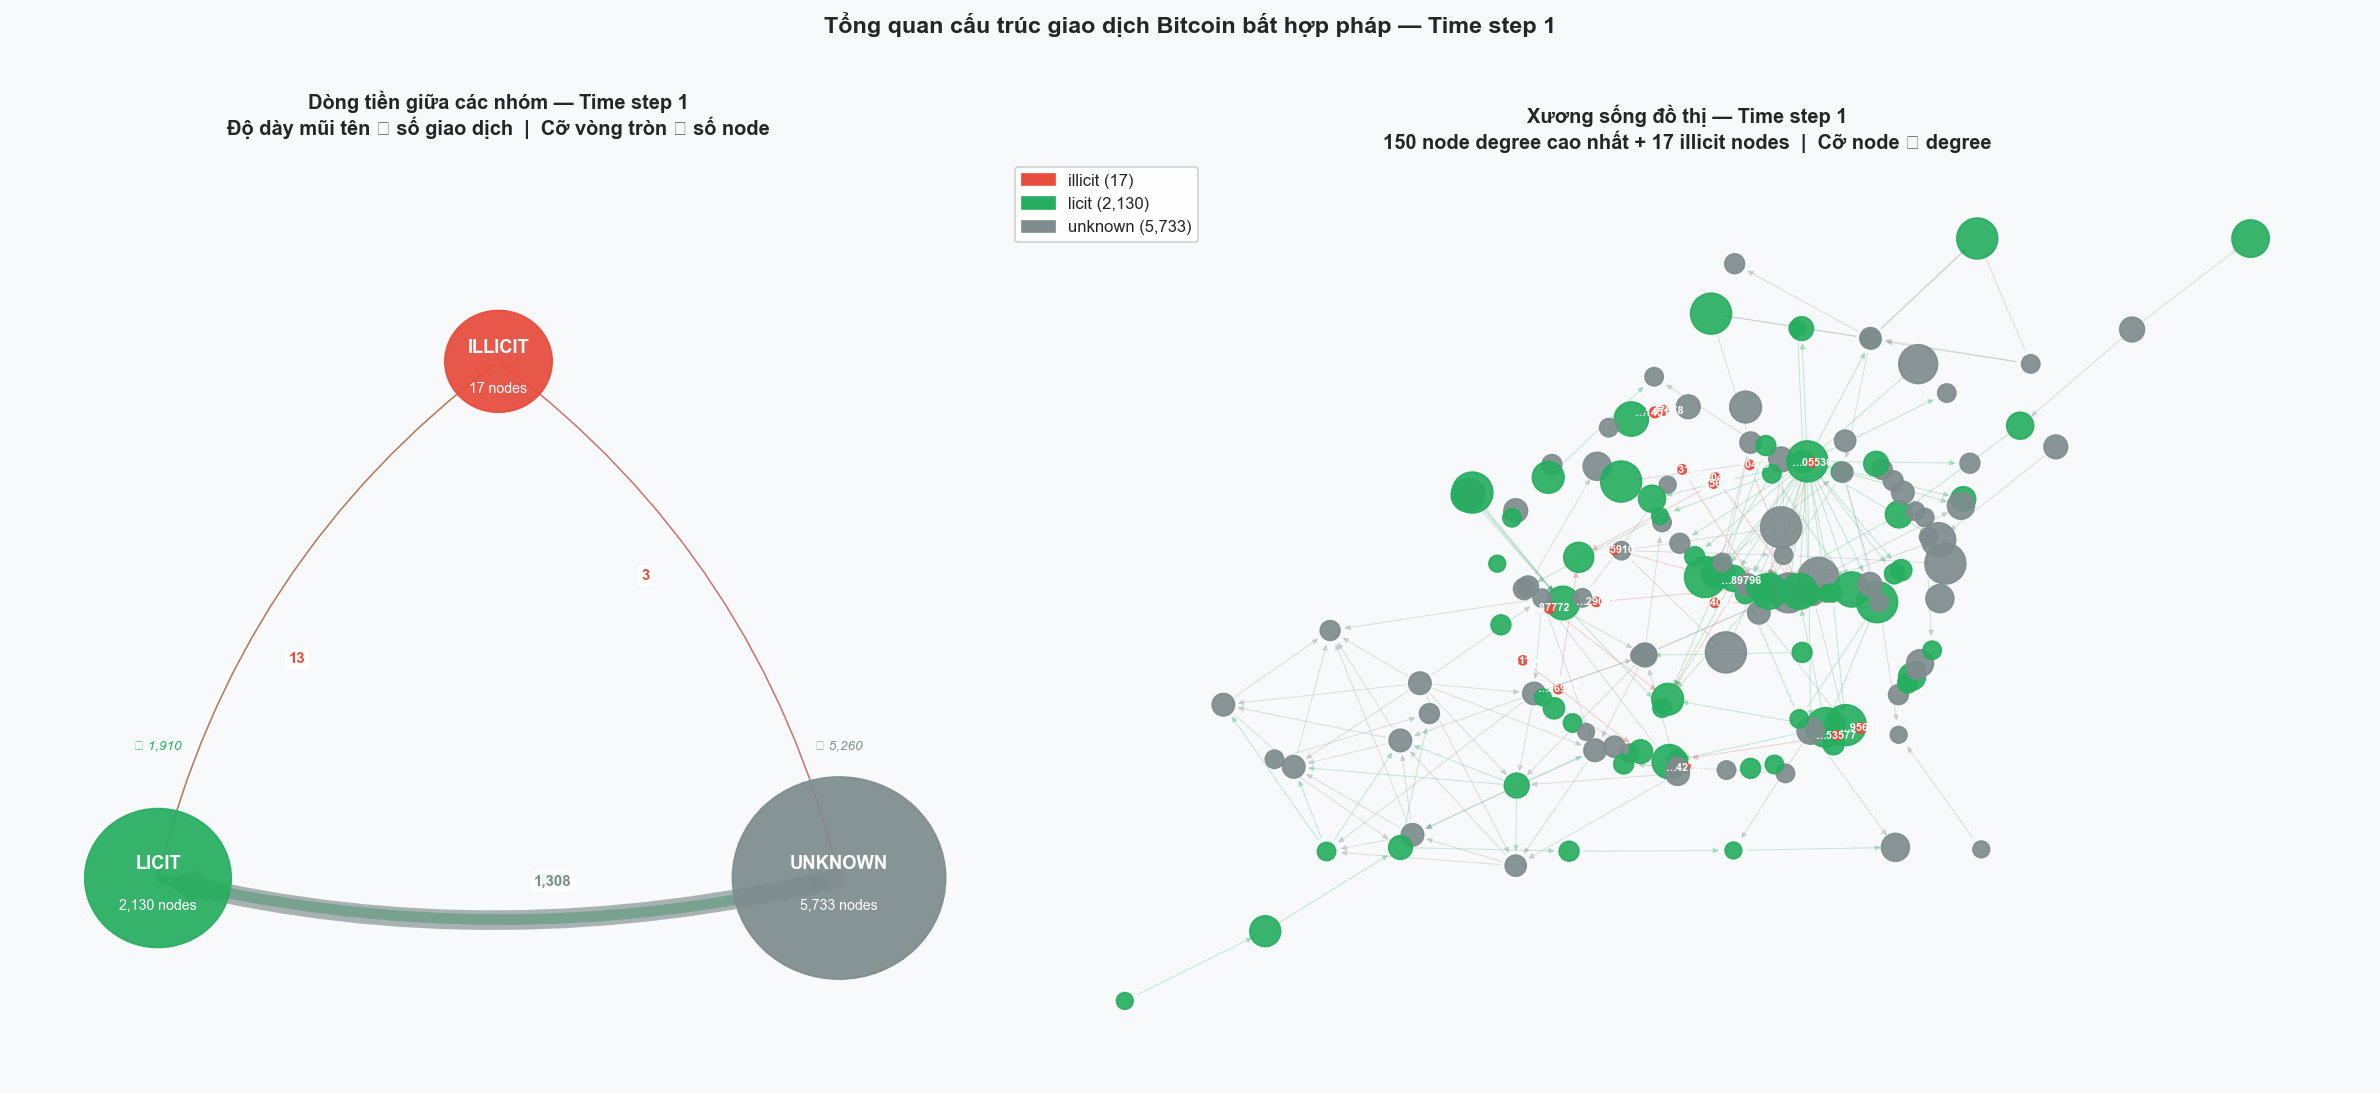

In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import numpy as np
from collections import defaultdict

target_ts = 1
ts_nodes = set(df_feat[df_feat['time_step']==target_ts]['txId'])
ts_edges = df_edges[df_edges['txId1'].isin(ts_nodes) & df_edges['txId2'].isin(ts_nodes)]
G_sub    = nx.from_pandas_edgelist(ts_edges, 'txId1', 'txId2', create_using=nx.DiGraph())
cls_map  = dict(zip(df_cls['txId'], df_cls['class']))

def cls_label(n):
    c = cls_map.get(n, 'unknown')
    return 'illicit' if c=='1' else 'licit' if c=='2' else 'unknown'

COL = {'illicit': '#e74c3c', 'licit': '#27ae60', 'unknown': '#7f8c8d'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9),
                                gridspec_kw={'width_ratios': [1, 1.4]})
fig.patch.set_facecolor('#f8f9fa')
for ax in (ax1, ax2):
    ax.set_facecolor('#f8f9fa')

# ═══════════════════════════════════════════════════════════════════════
# PANEL 1 — Aggregate flow: dòng tiền giữa 3 nhóm
# ═══════════════════════════════════════════════════════════════════════
ax1.set_xlim(0, 1); ax1.set_ylim(0, 1); ax1.axis('off')

# Đếm edges & nodes theo class
edge_flows  = defaultdict(int)
node_counts = defaultdict(int)
for u, v in G_sub.edges():
    edge_flows[(cls_label(u), cls_label(v))] += 1
for n in G_sub.nodes():
    node_counts[cls_label(n)] += 1

# Vị trí 3 nhóm (tam giác)
POS = {'illicit': np.array([0.50, 0.78]),
       'licit':   np.array([0.15, 0.22]),
       'unknown': np.array([0.85, 0.22])}

# Độ cong mũi tên (2 chiều không đè nhau)
ARC = {('illicit','licit'):   0.18, ('licit','illicit'):   -0.18,
       ('illicit','unknown'): -0.18, ('unknown','illicit'):  0.18,
       ('licit','unknown'):    0.12, ('unknown','licit'):   -0.12}

# Vẽ mũi tên trước (để circles đè lên)
max_flow = max((v for (s,d),v in edge_flows.items() if s!=d), default=1)
for (src, dst), count in sorted(edge_flows.items(), key=lambda x: x[1]):
    if src == dst:
        continue
    p1, p2 = POS[src], POS[dst]
    lw  = 0.8 + 11 * (count / max_flow)
    rad = ARC.get((src, dst), 0.15)

    ax1.annotate('', xy=p2, xytext=p1,
                 arrowprops=dict(
                     arrowstyle='->', color=COL[src], lw=lw, alpha=0.65,
                     connectionstyle=f'arc3,rad={rad}',
                     mutation_scale=18))

    # Label số lượng cạnh (đặt lệch theo hướng cong)
    t = 0.5 + 0.08 * np.sign(rad)
    mx = p1[0]*(1-t) + p2[0]*t + 0.04*rad*(p2[1]-p1[1])
    my = p1[1]*(1-t) + p2[1]*t - 0.04*rad*(p2[0]-p1[0])
    ax1.text(mx, my, f'{count:,}', ha='center', va='center', fontsize=9,
             fontweight='bold', color=COL[src],
             bbox=dict(facecolor='white', alpha=0.88,
                       boxstyle='round,pad=0.25', edgecolor='none'))

# Vẽ circle mỗi nhóm (kích thước ∝ số node)
total_nodes = sum(node_counts.values())
for cls_name, pos in POS.items():
    n   = node_counts[cls_name]
    r   = 0.055 + 0.075 * (n / total_nodes)
    ax1.add_patch(plt.Circle(pos, r, color=COL[cls_name], zorder=5, alpha=0.93))
    ax1.text(pos[0], pos[1]+0.015, cls_name.upper(),
             ha='center', va='center', fontsize=11, fontweight='bold',
             color='white', zorder=6)
    ax1.text(pos[0], pos[1]-0.03, f'{n:,} nodes',
             ha='center', va='center', fontsize=8.5, color='white', zorder=6)

# Self-loop (giao dịch trong cùng nhóm) — chú thích riêng
for cls_name in ['illicit', 'licit', 'unknown']:
    self_count = edge_flows.get((cls_name, cls_name), 0)
    if self_count:
        pos = POS[cls_name]
        ax1.text(pos[0], pos[1]+0.14, f'↺ {self_count:,}',
                 ha='center', fontsize=8, color=COL[cls_name],
                 style='italic')

ax1.set_title(f'Dòng tiền giữa các nhóm — Time step {target_ts}\n'
              f'Độ dày mũi tên ∝ số giao dịch  |  Cỡ vòng tròn ∝ số node',
              fontsize=12, fontweight='bold', pad=14)

# ═══════════════════════════════════════════════════════════════════════
# PANEL 2 — Backbone graph: top-150 node theo degree + toàn bộ illicit
# ═══════════════════════════════════════════════════════════════════════
degrees     = dict(G_sub.degree())
illicit_set = {n for n in G_sub.nodes() if cls_label(n) == 'illicit'}
top_nodes   = set(sorted(degrees, key=degrees.get, reverse=True)[:150])
backbone    = top_nodes | illicit_set
G_bb        = G_sub.subgraph(backbone).copy()

# Node style
nc, ns = [], []
for n in G_bb.nodes():
    cl = cls_label(n)
    nc.append(COL[cl])
    ns.append(max(30, min(600, degrees[n] * 20)))

# Edge màu theo nguồn
ec = [COL[cls_label(u)] for u, v in G_bb.edges()]

pos = nx.kamada_kawai_layout(G_bb, weight=None)

nx.draw_networkx_edges(G_bb, pos, ax=ax2, edge_color=ec,
                        alpha=0.25, arrows=True, arrowsize=7, width=0.6)
nx.draw_networkx_nodes(G_bb, pos, ax=ax2, node_color=nc,
                        node_size=ns, alpha=0.92)

# Chỉ label illicit
nx.draw_networkx_labels(G_bb, pos, ax=ax2,
    labels={n: f'…{str(n)[-5:]}' for n in G_bb.nodes()
            if cls_label(n) == 'illicit'},
    font_size=6.5, font_color='white', font_weight='bold')

ax2.legend(handles=[mpatches.Patch(color=c, label=f'{k} ({node_counts[k]:,})')
                    for k, c in COL.items()],
           loc='upper left', fontsize=10, framealpha=0.9)
ax2.set_title(
    f'Xương sống đồ thị — Time step {target_ts}\n'
    f'150 node degree cao nhất + {len(illicit_set)} illicit nodes  |  '
    f'Cỡ node ∝ degree',
    fontsize=12, fontweight='bold')
ax2.axis('off')

plt.suptitle('Tổng quan cấu trúc giao dịch Bitcoin bất hợp pháp — Time step 1',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('timestep1_overview.png', dpi=150, bbox_inches='tight')
plt.show()

### **Analysis of Concept Drift (Time Steps 43-49)**
The following analysis provides quantitative evidence for excluding time steps 43-49 from the main evaluation scope.

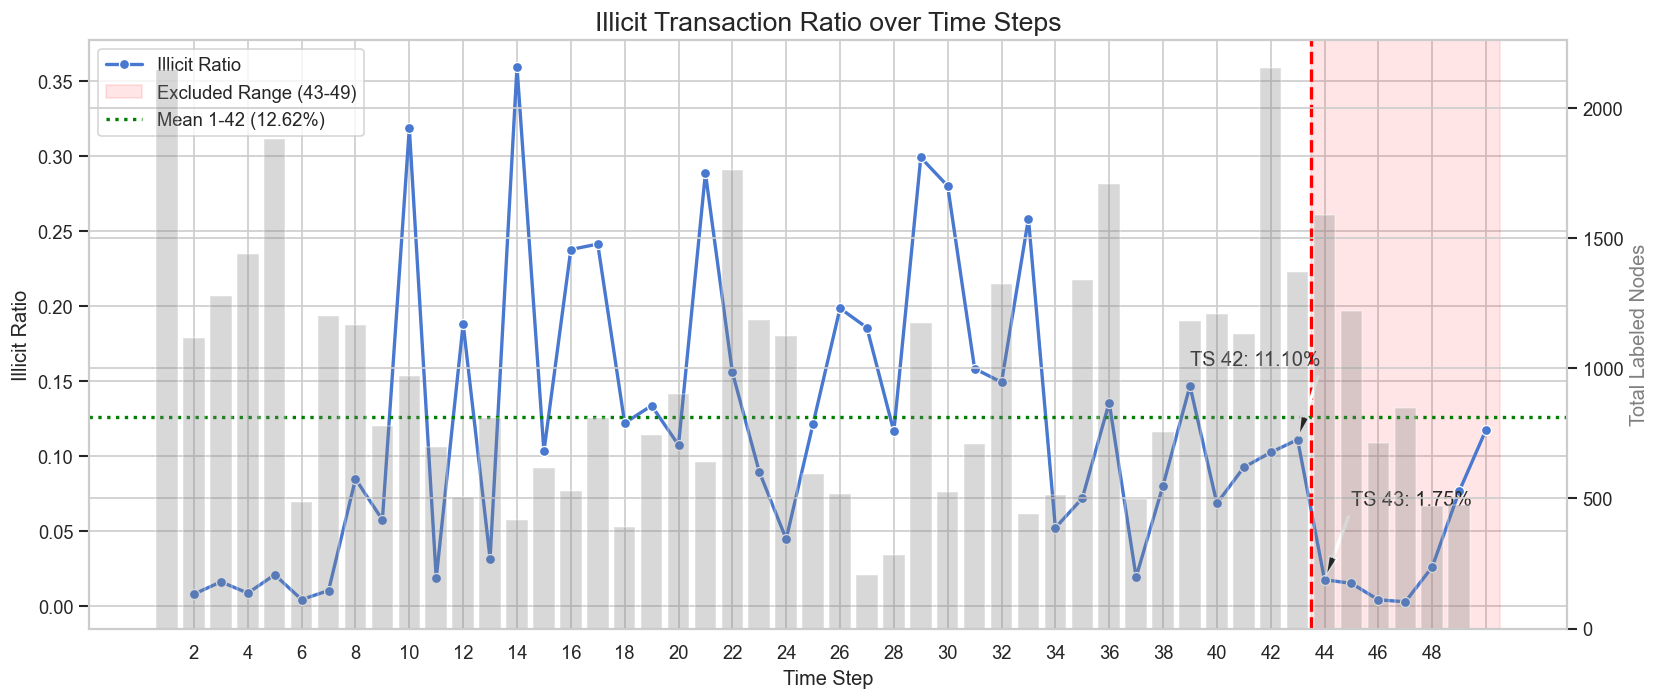

--- Statistics for Time Steps 43-49 ---


,time_step,total_labeled,illicit_count,illicit_ratio_%
0,43,1370,24,1.75
1,44,1591,24,1.51
2,45,1221,5,0.41
3,46,712,2,0.28
4,47,846,22,2.60
5,48,471,36,7.64
6,49,476,56,11.76



Total labeled nodes in 43-49: 6687
Total illicit nodes in 43-49: 169
Overall illicit ratio in 43-49 (pooled): 2.53%

--- Comparison: Steps 1-42 vs Steps 43-49 ---


,mean,std,min,max,CV (Std/Mean)
period,,,,,
Steps 1-42,0.1262,0.0954,0.0043,0.3597,0.7559
Steps 43-49,0.0371,0.0434,0.0028,0.1176,1.1698


In [20]:
# 1. Calculate illicit ratio per time step
labeled_df = df_cls[df_cls['class'] != 'unknown'].merge(df_feat[['txId', 'time_step']], on='txId', how='left')
labeled_df['is_illicit'] = (labeled_df['class'] == '1').astype(int)

ratio_df = labeled_df.groupby('time_step').agg(
    total_labeled=('txId', 'count'),
    illicit_count=('is_illicit', 'sum')
).reset_index()

ratio_df['illicit_ratio'] = ratio_df['illicit_count'] / ratio_df['total_labeled']

# 2. Plotting the ratio with twinx for sample size
fig, ax1 = plt.subplots(figsize=(14, 6))

sns.lineplot(data=ratio_df, x='time_step', y='illicit_ratio', marker='o', color='b', linewidth=2, label='Illicit Ratio', ax=ax1)

# Twin axis for sample size
ax2 = ax1.twinx()
sns.barplot(data=ratio_df, x='time_step', y='total_labeled', alpha=0.3, color='gray', ax=ax2)
ax2.set_ylabel('Total Labeled Nodes', color='gray', fontsize=12)

# Highlight time steps 43-49
ax1.axvspan(42.5, 49.5, color='red', alpha=0.1, label='Excluded Range (43-49)')
ax1.axvline(x=42.5, color='red', linestyle='--', linewidth=2)

# Mean baseline 1-42
mean_1_42 = ratio_df[ratio_df['time_step'] <= 42]['illicit_ratio'].mean()
ax1.axhline(y=mean_1_42, color='green', linestyle=':', linewidth=2, label=f'Mean 1-42 ({mean_1_42*100:.2f}%)')

# Annotations
ratio_42 = ratio_df[ratio_df['time_step'] == 42]['illicit_ratio'].values[0]
ratio_43 = ratio_df[ratio_df['time_step'] == 43]['illicit_ratio'].values[0]
ax1.annotate(f'TS 42: {ratio_42*100:.2f}%', xy=(42, ratio_42), xytext=(38, ratio_42+0.05),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))
ax1.annotate(f'TS 43: {ratio_43*100:.2f}%', xy=(43, ratio_43), xytext=(44, ratio_43+0.05),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

ax1.set_title('Illicit Transaction Ratio over Time Steps', fontsize=16)
ax1.set_xlabel('Time Step', fontsize=12)
ax1.set_ylabel('Illicit Ratio', fontsize=12)
ax1.set_xticks(range(1, 50, 2))

# Combine legends from ax1
lines, labels = ax1.get_legend_handles_labels()
ax1.legend(lines, labels, loc='upper left')

plt.tight_layout()
plt.show()

# 3. Statistics for the excluded range (43-49)
print("--- Statistics for Time Steps 43-49 ---")
excluded_stats = ratio_df[ratio_df['time_step'] >= 43].copy().reset_index(drop=True)
excluded_stats['illicit_ratio_%'] = (excluded_stats['illicit_ratio'] * 100).round(2)
display(excluded_stats[['time_step', 'total_labeled', 'illicit_count', 'illicit_ratio_%']])

total_labeled_excluded = excluded_stats['total_labeled'].sum()
total_illicit_excluded = excluded_stats['illicit_count'].sum()
print(f"\nTotal labeled nodes in 43-49: {total_labeled_excluded}")
print(f"Total illicit nodes in 43-49: {total_illicit_excluded}")
print(f"Overall illicit ratio in 43-49 (pooled): {(total_illicit_excluded / total_labeled_excluded * 100):.2f}%")

# 4. Compare distributions (1-42 vs 43-49)
print("\n--- Comparison: Steps 1-42 vs Steps 43-49 ---")
ratio_df['period'] = np.where(ratio_df['time_step'] <= 42, 'Steps 1-42', 'Steps 43-49')
compare_stats = ratio_df.groupby('period')['illicit_ratio'].agg(['mean', 'std', 'min', 'max']).round(4)
compare_stats['CV (Std/Mean)'] = (compare_stats['std'] / compare_stats['mean']).round(4)
display(compare_stats)
